In [1]:
from google.colab import files

print("Upload your CSV files one by one...")
uploaded = files.upload()

Upload your CSV files one by one...


Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  Load all datasets
orders    = pd.read_csv("olist_orders_dataset.csv")
reviews   = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
products  = pd.read_csv("olist_products_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

#  shape of each table
print("Orders shape:     ", orders.shape)
print("Reviews shape:    ", reviews.shape)
print("Customers shape:  ", customers.shape)
print("Products shape:   ", products.shape)
print("Translation shape:", category_translation.shape)

Orders shape:      (99441, 8)
Reviews shape:     (99224, 7)
Customers shape:   (99441, 5)
Products shape:    (32951, 9)
Translation shape: (71, 2)


In [3]:
# See what columns I'm working  with
print("=== ORDERS ===")
print(orders.columns.tolist())
print(orders.head(3))

print("\n=== REVIEWS ===")
print(reviews.columns.tolist())

print("\n=== CUSTOMERS ===")
print(customers.columns.tolist())

=== ORDERS ===
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   
2          2018-08-08 13:50:00           2018-08-17 

In [4]:
#  Convert date columns to datetime
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print(" Date columns converted successfully")
print(orders.dtypes)

 Date columns converted successfully
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [5]:
#performing joins, Step 1: Join reviews onto orders (on order_id)
# I used LEFT join to keep ALL orders, even those with no review
df = orders.merge(reviews, on="order_id", how="left")

print("After joining reviews:")
print(f"  Orders rows:  {len(orders)}")
print(f"  Merged rows:  {len(df)}")
print(f"   Difference: {len(df) - len(orders)} extra rows (should be 0 or very small)")

After joining reviews:
  Orders rows:  99441
  Merged rows:  99992
   Difference: 551 extra rows (should be 0 or very small)


In [6]:
#  Fix duplicates: keep only the latest review per order
reviews_clean = (
    reviews
    .sort_values("review_answer_timestamp", ascending=False)
    .drop_duplicates(subset="order_id", keep="first")
)

print(f"Reviews before dedup: {len(reviews)}")
print(f"Reviews after dedup:  {len(reviews_clean)}")

Reviews before dedup: 99224
Reviews after dedup:  98673


In [8]:
# Step 2: Re-join with the clean reviews
df = orders.merge(reviews_clean, on="order_id", how="left")

print(f"\nAfter clean join:")
print(f"  Orders rows: {len(orders)}")
print(f"  Merged rows: {len(df)}")
print(" Row counts match — no duplicates!" if len(df) == len(orders) else " Still duplicates — investigate!")


After clean join:
  Orders rows: 99441
  Merged rows: 99441
 Row counts match — no duplicates!


In [9]:
# Step 3: Join customers onto the result
df = df.merge(customers, on="customer_id", how="left")

print(f"\nFinal master table shape: {df.shape}")
print(f"\nColumns available:")
print(df.columns.tolist())


Final master table shape: (99441, 18)

Columns available:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [10]:
# Preview the master table
df[["order_id", "customer_state", "review_score",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"]].head(5)

,order_id,customer_state,review_score,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,SP,4.0,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,BA,4.0,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,GO,5.0,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,RN,5.0,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,SP,5.0,2018-02-16 18:17:02,2018-02-26


In [12]:
# Calculate the delay between estimated and actual delivery
# Positive = delivered BEFORE estimate (good)
# Negative = delivered AFTER estimate (late!)

df["days_difference"] = (
    df["order_estimated_delivery_date"] - df["order_delivered_customer_date"]
).dt.days

print("days_difference column created")
print(df["days_difference"].describe())

days_difference column created
count    96476.000000
mean        10.876881
std         10.183854
min       -189.000000
25%          6.000000
50%         11.000000
75%         16.000000
max        146.000000
Name: days_difference, dtype: float64


In [13]:
# Check order statuses
print("Order status breakdown:")
print(df["order_status"].value_counts())

Order status breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [14]:
# Separate delivered orders from undelivered
# Canceled/unavailable orders have no delivery date — exclude them
df_undelivered = df[df["order_status"].isin(["canceled", "unavailable"])].copy()
df_delivered   = df[df["order_status"] == "delivered"].copy()

# Also drop rows where delivery date is missing (edge cases)
df_delivered = df_delivered.dropna(subset=["order_delivered_customer_date",
                                            "order_estimated_delivery_date"])

print(f"\nDelivered orders:   {len(df_delivered)}")
print(f"Undelivered orders: {len(df_undelivered)}")
print(f"Other statuses:     {len(df) - len(df_delivered) - len(df_undelivered)}")


Delivered orders:   96470
Undelivered orders: 1234
Other statuses:     1737


In [16]:
#  Classify each order
def classify_delivery(days):
    if days >= 0:
        return "On Time"
    elif days >= -5:
        return "Late"
    else:
        return "Super Late"

df_delivered["delivery_status"] = df_delivered["days_difference"].apply(classify_delivery)

print("Delivery status breakdown:")
print(df_delivered["delivery_status"].value_counts())
print()

# Percentage breakdown
total = len(df_delivered)
for status, count in df_delivered["delivery_status"].value_counts().items():
    pct = (count / total) * 100
    print(f"  {status:12s}: {count:,}  ({pct:.1f}%)")

Delivery status breakdown:
delivery_status
On Time       88644
Super Late     4211
Late           3615
Name: count, dtype: int64

  On Time     : 88,644  (91.9%)
  Super Late  : 4,211  (4.4%)
  Late        : 3,615  (3.7%)


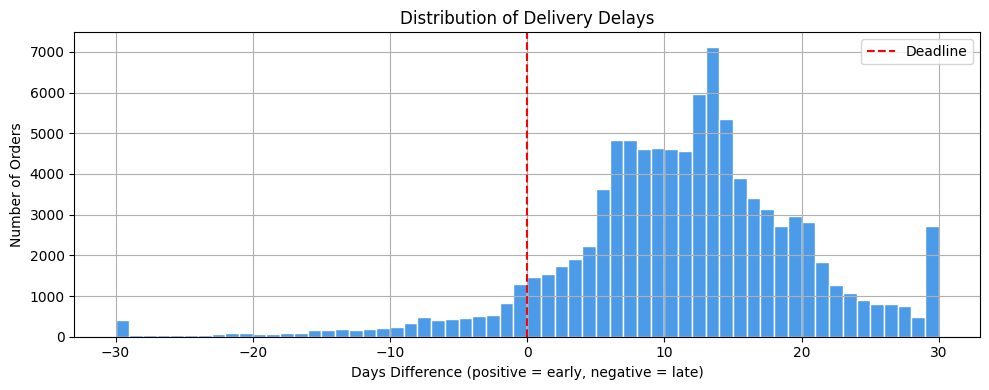

In [17]:
# Plot the distribution of delay days
fig, ax = plt.subplots(figsize=(10, 4))

df_delivered["days_difference"].clip(-30, 30).hist(
    bins=60, ax=ax, color="#4C9BE8", edgecolor="white"
)

ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Deadline")
ax.set_xlabel("Days Difference (positive = early, negative = late)")
ax.set_ylabel("Number of Orders")
ax.set_title("Distribution of Delivery Delays")
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
#  Calculate late % per state
state_stats = df_delivered.groupby("customer_state").agg(
    total_orders   = ("order_id", "count"),
    late_orders    = ("delivery_status", lambda x: (x != "On Time").sum())
).reset_index()

state_stats["late_pct"] = (state_stats["late_orders"] / state_stats["total_orders"] * 100).round(1)
state_stats = state_stats.sort_values("late_pct", ascending=False)

print(state_stats.head(10))

   customer_state  total_orders  late_orders  late_pct
1              AL           397           95      23.9
9              MA           717          141      19.7
16             PI           476           76      16.0
5              CE          1279          196      15.3
24             SE           335           51      15.2
4              BA          3256          457      14.0
18             RJ         12350         1664      13.5
26             TO           274           35      12.8
13             PA           946          117      12.4
21             RR            41            5      12.2


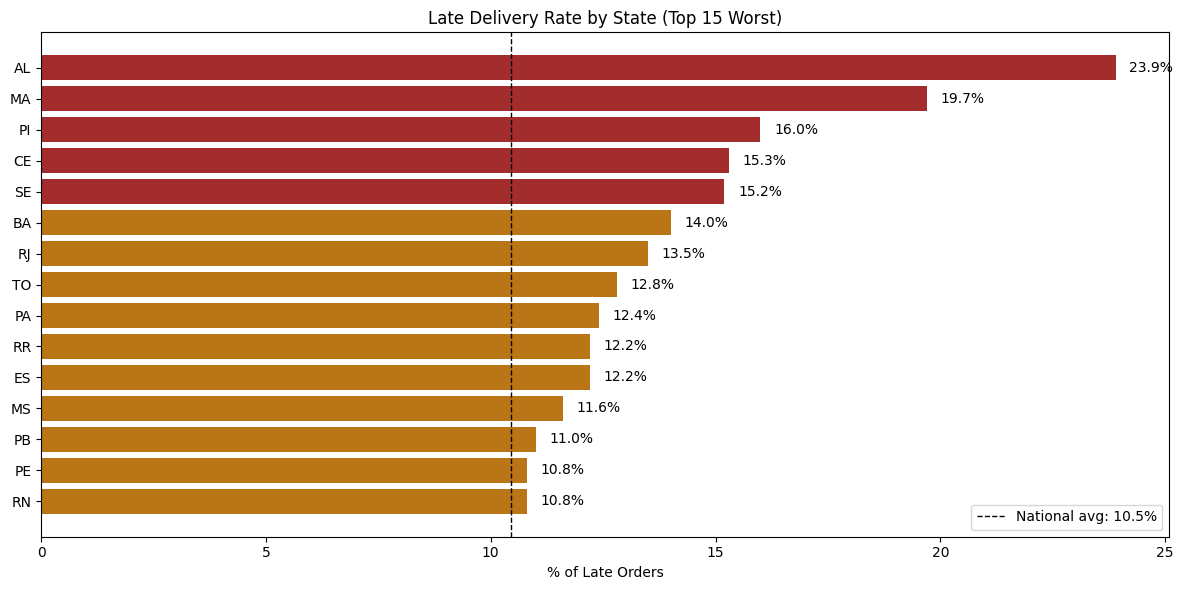


National average late rate: 10.5%
Worst state: AL at 23.9%


In [19]:
#  Bar chart: Top 15 worst states
top15 = state_stats.head(15)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#A32D2D" if pct > 15 else "#BA7517" if pct > 8 else "#4C9BE8"
          for pct in top15["late_pct"]]

bars = ax.barh(top15["customer_state"], top15["late_pct"], color=colors)

# Add value labels on each bar
for bar, val in zip(bars, top15["late_pct"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val}%", va="center", fontsize=10)

ax.set_xlabel("% of Late Orders")
ax.set_title("Late Delivery Rate by State (Top 15 Worst)")
ax.invert_yaxis()
ax.axvline(state_stats["late_pct"].mean(), color="black",
           linestyle="--", linewidth=1, label=f"National avg: {state_stats['late_pct'].mean():.1f}%")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nNational average late rate: {state_stats['late_pct'].mean():.1f}%")
print(f"Worst state: {state_stats.iloc[0]['customer_state']} at {state_stats.iloc[0]['late_pct']}%")

In [20]:
# Average review score by delivery status
sentiment = df_delivered.groupby("delivery_status")["review_score"].mean().round(2)
print("Average review score by delivery status:")
print(sentiment)

Average review score by delivery status:
delivery_status
Late          3.46
On Time       4.29
Super Late    1.78
Name: review_score, dtype: float64


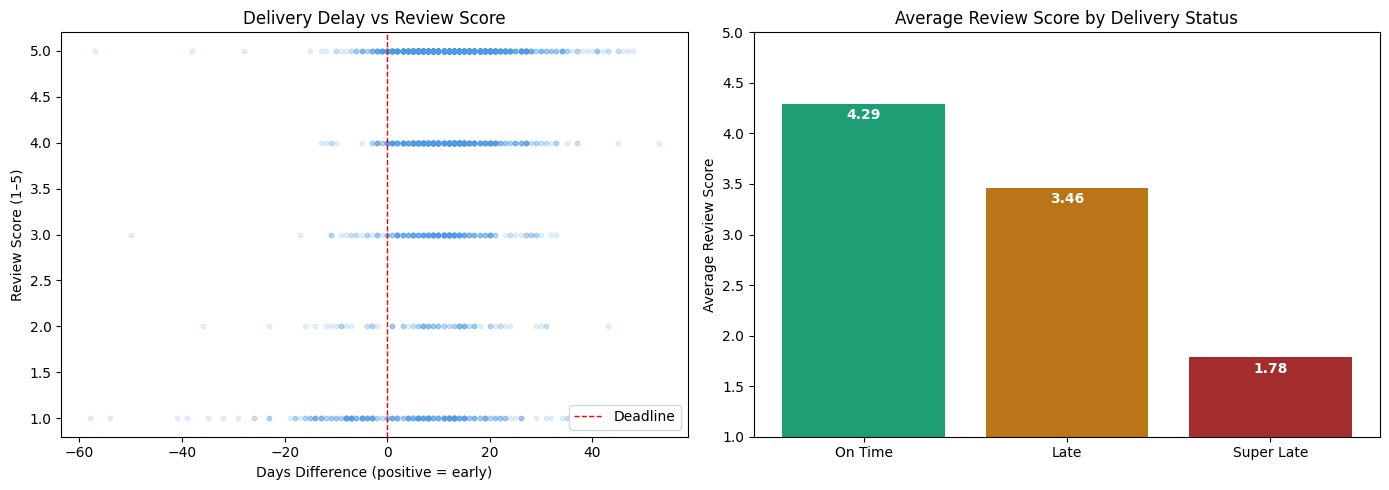

In [22]:
#  Scatter: delay days vs review score
# Sample 3000 rows so the chart isn't too heavy
sample = df_delivered.dropna(subset=["review_score"]).sample(3000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Scatter plot
axes[0].scatter(sample["days_difference"], sample["review_score"],
                alpha=0.15, color="#4C9BE8", s=10)
axes[0].set_xlabel("Days Difference (positive = early)")
axes[0].set_ylabel("Review Score (1–5)")
axes[0].set_title("Delivery Delay vs Review Score")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1, label="Deadline")
axes[0].legend()

# Chart 2: Average score per status
status_order  = ["On Time", "Late", "Super Late"]
status_colors = ["#1D9E75", "#BA7517", "#A32D2D"]
avg_scores = [df_delivered[df_delivered["delivery_status"] == s]["review_score"].mean()
              for s in status_order]

bars = axes[1].bar(status_order, avg_scores, color=status_colors)
axes[1].set_ylim(1, 5)
axes[1].set_ylabel("Average Review Score")
axes[1].set_title("Average Review Score by Delivery Status")
for bar, val in zip(bars, avg_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.15,
                 f"{val:.2f}", ha="center", color="white", fontweight="bold")

plt.tight_layout()
plt.show()

In [23]:
#  Join products onto orders to get category names
# First join order_items to get product_id per order
# Since we may not have order_items loaded, let's load it now
from google.colab import files
print("Upload olist_order_items_dataset.csv")
uploaded = files.upload()

Upload olist_order_items_dataset.csv


Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv


In [24]:
order_items = pd.read_csv("olist_order_items_dataset.csv")

# Join products to order_items, then translate
products_translated = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

# Join order_items to get product per order
orders_with_items = order_items[["order_id", "product_id"]].merge(
    products_translated[["product_id", "product_category_name",
                          "product_category_name_english"]],
    on="product_id",
    how="left"
)

# One product per order (take first item)
orders_with_items = orders_with_items.drop_duplicates(subset="order_id", keep="first")

# Add to master delivered table
df_delivered = df_delivered.merge(
    orders_with_items[["order_id", "product_category_name_english"]],
    on="order_id",
    how="left"
)

print("Sample categories:")
print(df_delivered["product_category_name_english"].value_counts().head(10))

Sample categories:
product_category_name_english
bed_bath_table           9167
health_beauty            8608
sports_leisure           7490
computers_accessories    6500
furniture_decor          6213
housewares               5688
watches_gifts            5470
telephony                4076
auto                     3792
toys                     3778
Name: count, dtype: int64


In [25]:
# Here we see Which categories have the worst late delivery rate?
category_stats = df_delivered.groupby("product_category_name_english").agg(
    total   = ("order_id", "count"),
    late    = ("delivery_status", lambda x: (x != "On Time").sum())
).reset_index()

category_stats["late_pct"] = (category_stats["late"] / category_stats["total"] * 100).round(1)

# Im going to keep categories with enough orders to be meaningful
category_stats = category_stats[category_stats["total"] >= 100]
category_stats = category_stats.sort_values("late_pct", ascending=False)

print("Top 10 worst categories for late delivery:")
print(category_stats.head(10)[["product_category_name_english", "total", "late_pct"]])

Top 10 worst categories for late delivery:
      product_category_name_english  total  late_pct
4                             audio    344      13.1
33          fashion_underwear_beach    117      12.8
10                  books_technical    255      11.0
47                     home_confort    370      10.3
36                             food    435      10.1
26                      electronics   2507       9.9
12               christmas_supplies    125       9.6
6                              baby   2763       9.3
17  construction_tools_construction    728       9.2
57                 office_furniture   1246       9.2


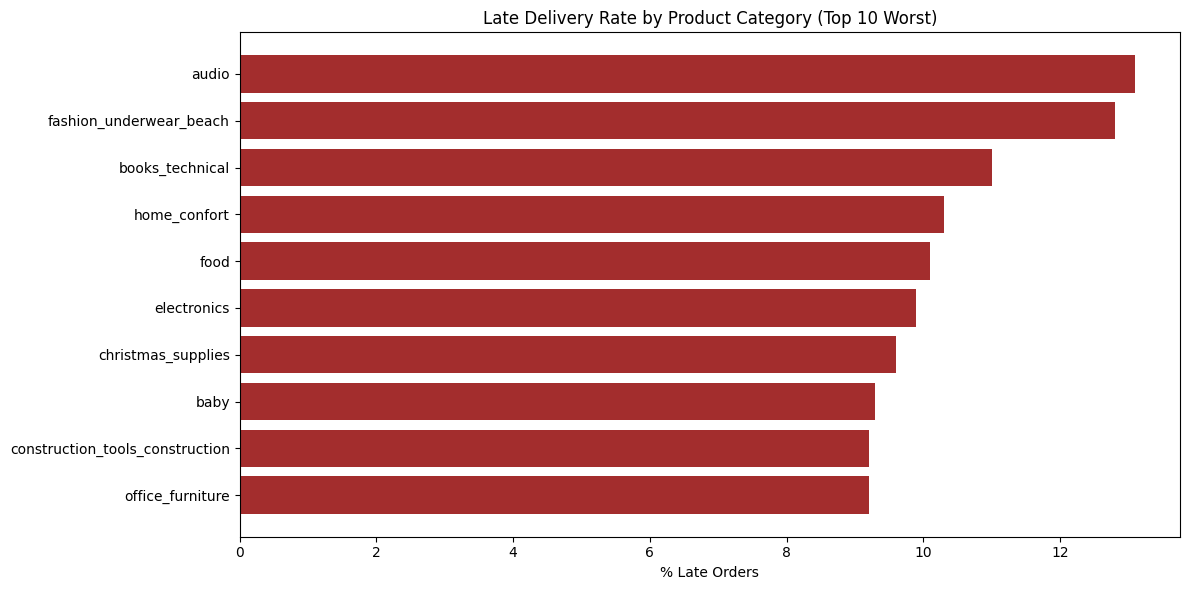

In [26]:
# Chart: Top 10 worst categories
top10_cat = category_stats.head(10)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top10_cat["product_category_name_english"],
        top10_cat["late_pct"], color="#A32D2D")
ax.set_xlabel("% Late Orders")
ax.set_title("Late Delivery Rate by Product Category (Top 10 Worst)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [27]:
#  Extract month from purchase date (My choice :Monthly trend analysis
# I recommend a monthly late rate trend because it shows whether the problem is getting better or worse over time, which is highly actionable for the business.).
df_delivered["order_month"] = df_delivered["order_purchase_timestamp"].dt.to_period("M")

monthly = df_delivered.groupby("order_month").agg(
    total_orders = ("order_id", "count"),
    late_orders  = ("delivery_status", lambda x: (x != "On Time").sum())
).reset_index()

monthly["late_pct"]    = (monthly["late_orders"] / monthly["total_orders"] * 100).round(1)
monthly["order_month"] = monthly["order_month"].astype(str)

print(monthly.tail(12))

   order_month  total_orders  late_orders  late_pct
11     2017-09          4150          216       5.2
12     2017-10          4478          237       5.3
13     2017-11          7288         1043      14.3
14     2017-12          5513          462       8.4
15     2018-01          7069          464       6.6
16     2018-02          6555         1048      16.0
17     2018-03          7003         1496      21.4
18     2018-04          6798          361       5.3
19     2018-05          6749          556       8.2
20     2018-06          6096           83       1.4
21     2018-07          6156          276       4.5
22     2018-08          6351          660      10.4


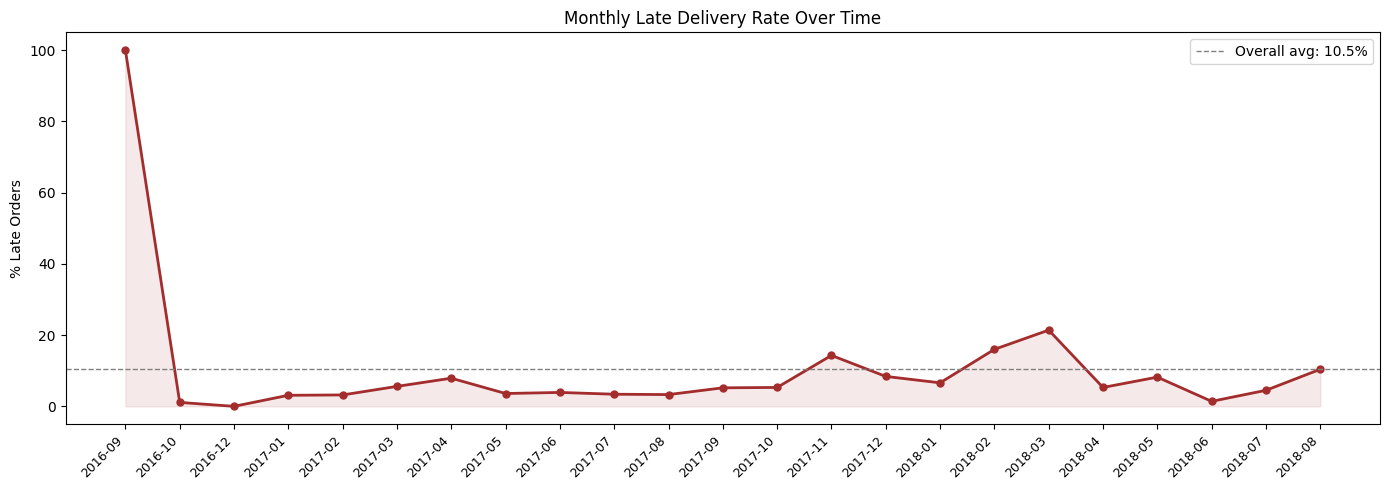

In [28]:
# Line chart: Late rate over time
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly["order_month"], monthly["late_pct"],
        marker="o", color="#A32D2D", linewidth=2, markersize=5)

ax.fill_between(range(len(monthly)), monthly["late_pct"],
                alpha=0.1, color="#A32D2D")

ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly["order_month"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("% Late Orders")
ax.set_title("Monthly Late Delivery Rate Over Time")
ax.axhline(monthly["late_pct"].mean(), color="gray",
           linestyle="--", linewidth=1,
           label=f"Overall avg: {monthly['late_pct'].mean():.1f}%")
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
# Export the final clean dataset
df_delivered.to_csv("veridi_master_dataset.csv", index=False)
print(f"Saved veridi_master_dataset.csv")
print(f"   Shape: {df_delivered.shape}")
print(f"   Columns: {df_delivered.columns.tolist()}")

Saved veridi_master_dataset.csv
   Shape: (96470, 22)
   Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'days_difference', 'delivery_status', 'product_category_name_english', 'order_month']


In [30]:
from google.colab import files
files.download("veridi_master_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>